In [172]:
#Bank Marketing Project
import pandas as pd
url = "https://raw.githubusercontent.com/madmashup/targeted-marketing-predictive-engine/master/banking.csv"

#Loading the data
data = pd.read_csv(url)

#Exploring Data
print(data.shape)
print(data.head())
print(data.info())
print(data.describe())

(41188, 21)
   age          job  marital          education  default housing loan  \
0   44  blue-collar  married           basic.4y  unknown     yes   no   
1   53   technician  married            unknown       no      no   no   
2   28   management   single  university.degree       no     yes   no   
3   39     services  married        high.school       no      no   no   
4   55      retired  married           basic.4y       no     yes   no   

    contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0  cellular   aug         thu  ...         1    999         0  nonexistent   
1  cellular   nov         fri  ...         1    999         0  nonexistent   
2  cellular   jun         thu  ...         3      6         2      success   
3  cellular   apr         fri  ...         2    999         0  nonexistent   
4  cellular   aug         fri  ...         1      3         1      success   

  emp_var_rate  cons_price_idx  cons_conf_idx  euribor3m  nr_employed  y  
0    

In [173]:
#Check for missing values
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [174]:
#Cleaning data
data['job'] = data['job'].replace('unknown', data['job'].mode()[0])
data['marital'] = data['marital'].replace('unknown', data['marital'].mode()[0])
data['education'] = data['education'].replace('unknown', data['education'].mode()[0])
data['default'] = data['default'].replace('unknown', data['default'].mode()[0])
data['housing'] = data['housing'].replace('unknown', data['housing'].mode()[0])
data['loan'] = data['loan'].replace('unknown', data['loan'].mode()[0])

In [175]:
#Check if the unknowns have been removed
print(data['job'].value_counts())
print(data['marital'].value_counts())
print(data['education'].value_counts())
print(data['default'].value_counts())
print(data['housing'].value_counts())
print(data['loan'].value_counts())

job
admin.           10752
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Name: count, dtype: int64
marital
married     25008
single      11568
divorced     4612
Name: count, dtype: int64
education
university.degree      13899
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
illiterate                18
Name: count, dtype: int64
default
no     41185
yes        3
Name: count, dtype: int64
housing
yes    22566
no     18622
Name: count, dtype: int64
loan
no     34940
yes     6248
Name: count, dtype: int64


In [176]:
#Encoding the strings
data = pd.get_dummies(data, columns=['job', 'marital', 'education',
'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'],
drop_first=True)


In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Defining X and y
X = data.drop('y', axis=1)
y = data['y']

#Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42,
stratify=y)

#Standardizing X_train and X_test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Training the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#Prediction
y_pred = model.predict(X_test)

#Evaluating The model
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f"Accuracy Score: {acc * 100:.2f}%")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")

Accuracy Score: 91.16%

Confusion Matrix:
[[7123  187]
 [ 541  387]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.67      0.42      0.52       928

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



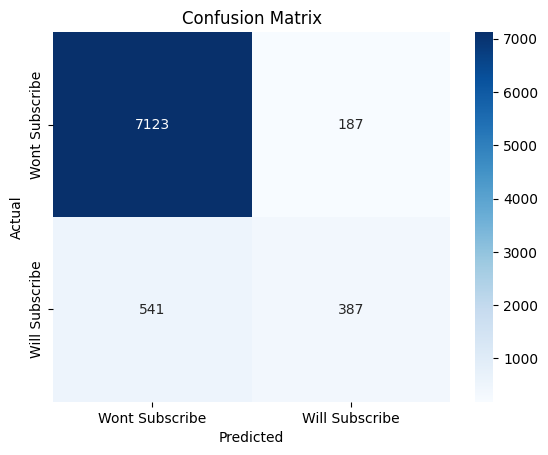

In [178]:
#Visualizing the data
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, fmt='d', annot=True,
cmap='Blues', xticklabels=['Wont Subscribe', 'Will Subscribe'],
yticklabels=['Wont Subscribe', 'Will Subscribe'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [179]:
# Start with all zeros!!
new_customers = pd.DataFrame(
    0,
    index=range(3),
    columns=X.columns
)

# Fill numerical columns
new_customers['age'] = [25, 45, 60]
new_customers['duration'] = [300, 150, 500]
new_customers['campaign'] = [1, 3, 2]
new_customers['pdays'] = [999, 999, 6]
new_customers['previous'] = [0, 0, 2]
new_customers['emp_var_rate'] = [1.4, -0.1, -1.7]
new_customers['cons_price_idx'] = [93.4, 93.2, 94.0]
new_customers['cons_conf_idx'] = [-36.1, -42.0, -39.8]
new_customers['euribor3m'] = [4.9, 4.0, 0.7]
new_customers['nr_employed'] = [5228.1, 5195.8, 4991.6]

# Fill categorical columns
# Customer 1 → technician, married, cellular
new_customers.loc[0, 'job_housemaid'] = 1
new_customers.loc[0, 'marital_married'] = 1
new_customers.loc[0, 'contact_telephone'] = 1
new_customers.loc[0, 'month_aug'] = 1

# Customer 2 → admin, single, cellular
new_customers.loc[1, 'job_services'] = 1
new_customers.loc[1, 'marital_single'] = 1
new_customers.loc[1, 'month_nov'] = 1

# Customer 3 → management, married
new_customers.loc[2, 'marital_married'] = 1
new_customers.loc[2, 'month_jun'] = 1
new_customers.loc[2, 'poutcome_success'] = 1

# Scale the new customers
new_scaled = scaler.transform(new_customers)

# Predict
pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

# Print results
for i, (p, pr) in enumerate(zip(pred, prob)):
    decision = "Will Subscribe" if p == 1 else "Won't Subscribe"
    confidence = round(pr.max() * 100, 1)
    print(f"Customer {i+1}: {decision} ({confidence}% confident)")

Customer 1: Won't Subscribe (98.9% confident)
Customer 2: Won't Subscribe (99.0% confident)
Customer 3: Will Subscribe (81.5% confident)
